# Linear Regression

Linear regression predicts a **continuous number** by fitting a straight line (or hyperplane) through the data: `y = m*x + b`. It is the simplest and most interpretable regression model.

**Topics covered in this notebook**

1. Intuition
2. Training on a dataset
3. Inspecting the model
4. When to use it

**1. Intuition**

The model learns a slope for each feature plus an intercept so the line sits as close as possible to all the points (minimizing squared error). Below is a one-feature fit - slope `m`, intercept `b` - and a prediction for a new `x`.

In [102]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Define data and fit model
x = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([2, 4, 5, 4, 6])
line = LinearRegression().fit(x, y)

In [103]:
# Keep your original console logs
print(f"slope (m): {line.coef_[0]:.2f}")
print(f"intercept (b): {line.intercept_:.2f}")
print("prediction at x=6:", round(line.predict([[6]])[0], 2))

slope (m): 0.80
intercept (b): 1.80
prediction at x=6: 6.6


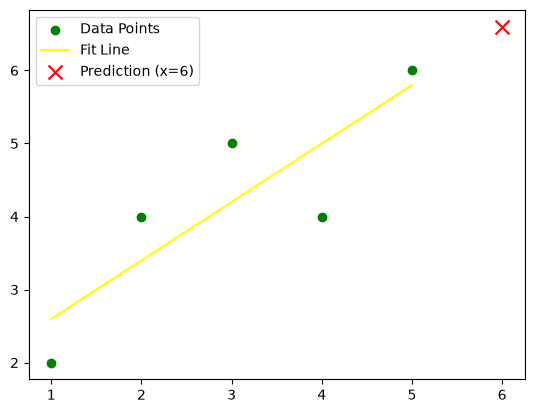

In [ ]:
# 2. Simplest Matplotlib visualization
plt.scatter(x, y, color="green", label="Data Points")  # Original scatter plot
plt.plot(x, line.predict(x), color="yellow", label="Fit Line")  # Best fit line
plt.scatter(6, line.predict([[6]]), color="red", marker="x", s=100, label="Prediction (x=6)")

plt.legend()
plt.show()

**2. Training on a Dataset**

The real workflow: load data, split into train/test, `fit` on the training set, then measure error on held-out data. We use the built-in diabetes dataset (10 features -> a continuous disease-progression score).

In [105]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

# R^2: fraction of variance explained (1.0 is perfect)
# RMSE: typical error in the target's units
print("R^2 :", round(r2_score(y_test, preds), 3))
print("RMSE:", round(mean_squared_error(y_test, preds) ** 0.5, 2))

R^2 : 0.453
RMSE: 53.85


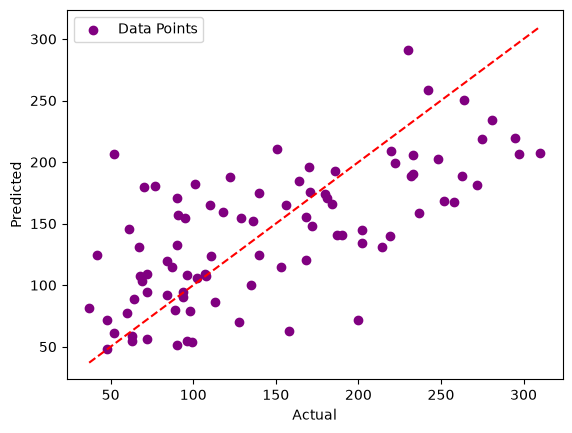

In [144]:
plt.scatter(y_test, preds, color="purple", label="Data Points")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()

In [106]:
print("predicted: ", preds[:5])
print("actual   : ", y_test[:5])

predicted:  [139.5475584  179.51720835 134.03875572 291.41702925 123.78965872]
actual   :  [219.  70. 202. 230. 111.]


**3. Inspecting the Model**

Linear regression is interpretable: each coefficient tells you how much the prediction changes per unit of that feature, and the intercept is the baseline.

In [107]:
print("intercept:", round(model.intercept_, 2))
print("number of coefficients:", len(model.coef_))
print("first 3 coefficients:", model.coef_[:3].round(2))

intercept: 151.35
number of coefficients: 10
first 3 coefficients: [  37.9  -241.96  542.43]


**4. When to Use It**

- Predicting a **continuous** value (price, score, demand).
- You want a fast, interpretable baseline.
- The relationship is roughly linear; scale features and watch for outliers, which pull the line.
- For classification (yes/no), reach for **logistic regression** instead.

In [ ]:
# Show the fit on ONE feature (BMI, the most influential) so it is easy to read.
# The full model uses all 10 features, so its predictions do not line up with BMI
# alone (the line would zigzag). We fit a separate BMI-only model purely to
# visualise the trend of that single feature.
bmi_train = X_train[:, 2].reshape(-1, 1)   # column 2 = BMI
bmi_test  = X_test[:, 2].reshape(-1, 1)

bmi_model = LinearRegression().fit(bmi_train, y_train)

order = bmi_test[:, 0].argsort()           # sort so the line draws left-to-right

plt.scatter(bmi_test[:, 0], y_test, color="green", alpha=0.6, label="Actual")
plt.plot(bmi_test[order, 0], bmi_model.predict(bmi_test[order]), color="red", label="BMI-only fit")
plt.xlabel("BMI (standardized)")
plt.ylabel("Disease progression")
plt.title("Diabetes: BMI vs Progression")
plt.legend()
plt.show()
